<a href="https://colab.research.google.com/github/Upasna20/CogniState/blob/main/model_notebook/FYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Part 1: Setup & Configuration**

In [ ]:
import pandas as pd
import numpy as np

#**Part 2: Feature Engineering(Loading & Cleaning and Micro-Feature Extraction (The Physics))**

In [ ]:
def compute_dwell_session(session_df):
    key_state = {}
    dwell_times = []

    for _, row in session_df.iterrows():
        key = row['key']
        event = row['event']

        if key not in key_state:
            key_state[key] = None

        if event == 'keydown':
            if key_state[key] is None:
                key_state[key] = row['timestamp']
            dwell_times.append(np.nan)

        elif event == 'keyup':
            if key_state[key] is not None:
                dwell = (row['timestamp'] - key_state[key]).total_seconds()
                dwell_times.append(dwell)
                key_state[key] = None
            else:
                dwell_times.append(np.nan)
        else:
            dwell_times.append(np.nan)

    session_df['dwell_time'] = dwell_times
    return session_df


In [ ]:
def process_data_pipeline(file_path):
    print("Loading data...")
    # Load specific columns to save memory
    df = pd.read_csv(file_path, sep='\t', usecols=['timestamp', 'xpos', 'ypos', 'key', 'event', 'user', 'session_id'])

    # A. Preprocessing
    # ----------------
    print("Preprocessing timestamps...")
    # Convert string timestamp to datetime object
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Sort is CRITICAL for calculating deltas (velocity/flight time)
    df = df.sort_values(by=['session_id', 'timestamp'])

    # B. Micro-Feature Extraction (Per Row)
    # -------------------------------------
    print("Calculating micro-features (velocity, angles)...")

    # --- Mouse Features ---
    # Filter only mouse move events for velocity calc
    mouse_mask = df['event'] == 'mousemove'

    # Calculate deltas (change in x, y, time) per session
    # We use .diff() to compare current row vs previous row
    df.loc[mouse_mask, 'dx'] = df.loc[mouse_mask].groupby('session_id')['xpos'].diff()
    df.loc[mouse_mask, 'dy'] = df.loc[mouse_mask].groupby('session_id')['ypos'].diff()
    df.loc[mouse_mask, 'dt'] = df.loc[mouse_mask].groupby('session_id')['timestamp'].diff().dt.total_seconds()

    # Filter out large gaps (e.g., user stepped away > 2s) to prevent zero-velocity skew
    valid_move = (df['dt'] > 0) & (df['dt'] < 2.0)

    # Euclidean Distance formula: sqrt(dx^2 + dy^2)
    df.loc[valid_move, 'dist'] = np.sqrt(df.loc[valid_move, 'dx']**2 + df.loc[valid_move, 'dy']**2)

    # Velocity = Distance / Time
    df.loc[valid_move, 'velocity'] = df.loc[valid_move, 'dist'] / df.loc[valid_move, 'dt']

    # --- Keyboard Features (UPDATED) ---
    print("Calculating Keyboard Flight & Dwell...")

    # Filter for Key events only
    key_df = df[df['event'].isin(['keydown', 'keyup'])].copy()
    # Ensure chronological order per session
    key_df = key_df.sort_values(by=['session_id', 'timestamp'])
    # Apply per session (important: group_keys=False)
    key_df = key_df.groupby('session_id', group_keys=False).apply(compute_dwell_session)

    # Write dwell_time back into main df using index alignment
    df.loc[key_df.index, 'dwell_time'] = key_df['dwell_time']

    # 2. Calculate Flight Time (Latency between keys)
    # This requires looking at the global time stream of keys
    key_stream = df[df['event'] == 'keydown'].copy() # Only look at when keys are pressed
    key_stream = key_stream.sort_values(by=['session_id', 'timestamp'])

    # Calculate time difference between THIS press and PREVIOUS press
    key_stream['flight_time'] = key_stream.groupby('session_id')['timestamp'].diff().dt.total_seconds()

    # Filter: Flight time < 2.0s (otherwise it's just a pause)
    valid_flight = (key_stream['flight_time'] > 0) & (key_stream['flight_time'] < 2.0)
    df.loc[valid_flight.index, 'flight_time'] = key_stream.loc[valid_flight, 'flight_time']

    # 3. Backspace (Keep it, but it's secondary now)
    # Check if key code is 8 or 'Backspace'
    df['is_backspace'] = df['key'].apply(lambda x: 1 if str(x) in ['8', 'Backspace'] else 0)
    # C. Window Aggregation (The Dataset Creation)
    # --------------------------------------------
    print("Aggregating into 30s windows...")

    # We group by User, Session, and 30-Second Time Chunks, defining the rule
    grouper = df.groupby(['user', 'session_id', pd.Grouper(key='timestamp', freq='30s')])

    features = pd.DataFrame()

    # 1. Mouse Dynamics (Motor Control)
    features['mouse_vel_mean']   = grouper['velocity'].mean()
    features['mouse_vel_std']    = grouper['velocity'].std()    # Jitter (Shaking)
    features['mouse_total_dist'] = grouper['dist'].sum()        # Workload (How much moved)

    # 2. Keyboard Dynamics (Cognitive Load)
    features['key_press_count']  = grouper.apply(lambda x: (x['event'] == 'keydown').sum()) # Typing Speed (WPM proxy)
    features['backspace_count']  = grouper['is_backspace'].sum()

    # --- NEW FEATURES ADDED HERE ---
    # Dwell Time: How long they hold a key down (0.1s vs 0.05s)
    features['key_dwell_mean']   = grouper['dwell_time'].mean()
    features['key_dwell_std']    = grouper['dwell_time'].std()  # Irregularity in hold time

    # Flight Time: The gap between keys (The "Rhythm")
    features['key_flight_mean']  = grouper['flight_time'].mean()
    features['key_flight_std']   = grouper['flight_time'].std() # Arrhythmia (Hesitation)

    # 3. Derived Metrics
    # Error Rate = Backspaces / Total Keys
    # We add +1 to denominator to prevent DivisionByZero errors in empty windows
    features['error_rate'] = features['backspace_count'] / (features['key_press_count'] + 1)

    # Cleanup: Fill NaNs
    # If no keys were pressed in a window, dwell/flight time will be NaN.
    # We fill with 0, but ideally, the model handles 0 as "No Data".
    features = features.fillna(0)
    features = features.reset_index()

    return (df, features)

In [ ]:
file_path = "/content/drive/MyDrive/Keystroke and Mouse Dynamics for UEBA Dataset/EVTRACKTRACK/EVTRACKTRACK.csv"

In [ ]:
(df, features) = process_data_pipeline(file_path)
features[
    (features['user'] == 'User1') &
    (features['session_id'] == 366771570) &
    (features['timestamp'] == pd.Timestamp('2020-02-17 15:21:00'))
]


Loading data...
Preprocessing timestamps...
Calculating micro-features (velocity, angles)...
Calculating Keyboard Flight & Dwell...


/tmp/ipykernel_2150/277338767.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  key_df = key_df.groupby('session_id', group_keys=False).apply(compute_dwell_session)


Aggregating into 30s windows...


/tmp/ipykernel_2150/277338767.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features['key_press_count']  = grouper.apply(lambda x: (x['event'] == 'keydown').sum()) # Typing Speed (WPM proxy)


,user,session_id,timestamp,mouse_vel_mean,mouse_vel_std,mouse_total_dist,key_press_count,backspace_count,key_dwell_mean,key_dwell_std,key_flight_mean,key_flight_std,error_rate
231,User1,366771570,2020-02-17 15:21:00,802.717076,425.785354,766.316455,18,18,0.349071,0.374313,0.24475,0.326709,0.947368


In [ ]:
print(df['user'].nunique())
print(df['session_id'].nunique())
print(features.shape)


12
195
(2121, 13)


In [ ]:
print(features.var(numeric_only=True))


session_id          6.855214e+09
mouse_vel_mean      3.150231e+05
mouse_vel_std       2.332837e+05
mouse_total_dist    2.650646e+06
key_press_count     1.737323e+03
backspace_count     1.658634e-01
key_dwell_mean      4.291284e+04
key_dwell_std       2.084933e+04
key_flight_mean     2.125597e-02
key_flight_std      1.537222e-02
error_rate          4.249323e-04
dtype: float64


array([[<Axes: title={'center': 'session_id'}>,
        <Axes: title={'center': 'timestamp'}>,
        <Axes: title={'center': 'mouse_vel_mean'}>],
       [<Axes: title={'center': 'mouse_vel_std'}>,
        <Axes: title={'center': 'mouse_total_dist'}>,
        <Axes: title={'center': 'key_press_count'}>],
       [<Axes: title={'center': 'backspace_count'}>,
        <Axes: title={'center': 'key_dwell_mean'}>,
        <Axes: title={'center': 'key_dwell_std'}>],
       [<Axes: title={'center': 'key_flight_mean'}>,
        <Axes: title={'center': 'key_flight_std'}>,
        <Axes: title={'center': 'error_rate'}>]], dtype=object)

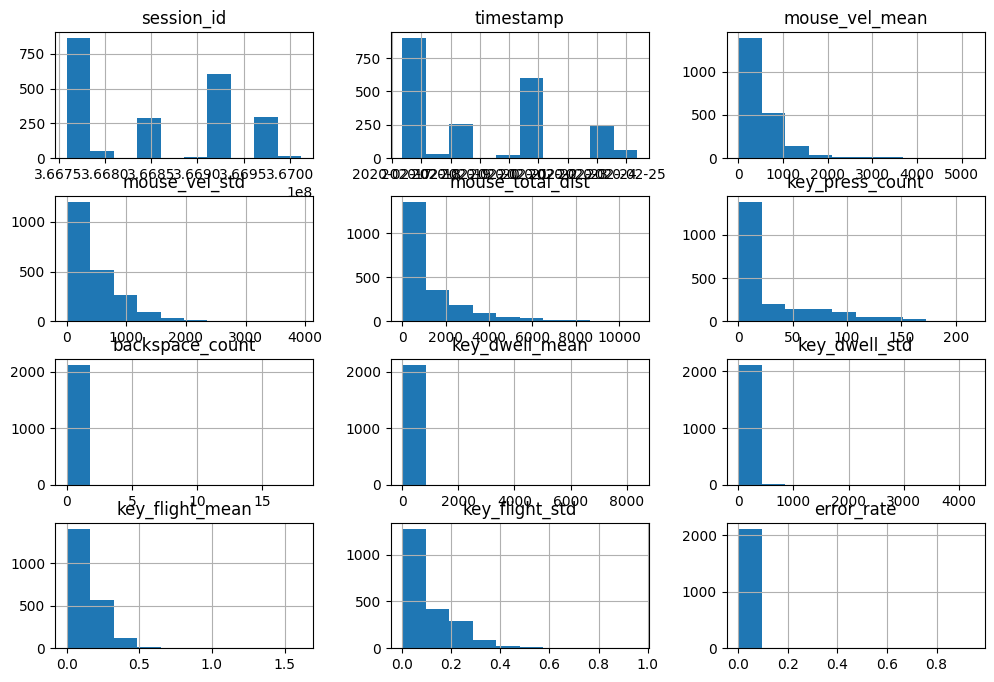

In [ ]:
features.hist(figsize=(12,8))


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
import pandas as pd

# 1. DEFINE THE FEATURES
# These are the 30-second summary metrics your script calculated
feature_cols = [
    'mouse_vel_mean', 'mouse_vel_std', 'mouse_total_dist',
    'key_press_count', 'backspace_count', 'key_dwell_mean',
    'key_dwell_std', 'key_flight_mean', 'key_flight_std', 'error_rate'
]

print("Cleaning data and dropping idle windows...")
# 2. CLEAN UP IDLE TIME
# We drop windows where the user did absolutely nothing so it doesn't skew their baseline
active_features = features[(features['key_press_count'] > 0) | (features['mouse_total_dist'] > 0)].copy()

# For windows where they moved the mouse but didn't type (leaving NaN for keyboard metrics),
# we fill those NaNs with the user's personal median, NOT zero.
for col in feature_cols:
    active_features[col] = active_features.groupby('user')[col].transform(lambda x: x.fillna(x.median()))
    active_features[col] = active_features[col].fillna(0) # Catch-all for extreme edge cases

print("Calculating personal baselines (Z-Scores) per user...")
# 3. THE SKILL-AGNOSTIC SCALER (Macro Baseline)
scaled_dataframes = []

# This loop is the magic: It isolates one user at a time.
for user, user_data in active_features.groupby('user'):
    scaler = StandardScaler()

    # Extract the raw 30s jitter/speed numbers
    user_features = user_data[feature_cols]

    # fit_transform calculates THIS user's global mean/std and applies the Z-score formula
    scaled_array = scaler.fit_transform(user_features)

    # Store the new Z-scores back into a dataframe safely
    scaled_df = user_data.copy()
    scaled_df[feature_cols] = scaled_array

    scaled_dataframes.append(scaled_df)

# Recombine everyone into one dataset.
# Now, '0' universally means 'Normal for this specific person'.
final_ml_dataset = pd.concat(scaled_dataframes)

print("Training the Unsupervised Anomaly Detector...")
# 4. TRAIN THE MODEL (One-Class SVM)
# nu=0.05 tells the model to assume about 5% of the data might be natural outliers/stress
svm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)

# Train the model on the newly scaled Z-scores
svm_model.fit(final_ml_dataset[feature_cols])

# 5. DETECT ANOMALIES (Stress/Cognitive Load)
# Predict outputs 1 for Normal, -1 for Anomaly
final_ml_dataset['is_anomalous'] = svm_model.predict(final_ml_dataset[feature_cols])

print("\n--- DETECTION COMPLETE ---")
print("Total 30-second windows analyzed:", len(final_ml_dataset))
print("Results Breakdown:")
print(" 1 = Normal State")
print("-1 = Anomalous/Stressed State")
print(final_ml_dataset['is_anomalous'].value_counts())

Cleaning data and dropping idle windows...
Calculating personal baselines (Z-Scores) per user...
Training the Unsupervised Anomaly Detector...

--- DETECTION COMPLETE ---
Total 30-second windows analyzed: 1844
Results Breakdown:
 1 = Normal State
-1 = Anomalous/Stressed State
is_anomalous
 1    1753
-1      91
Name: count, dtype: int64


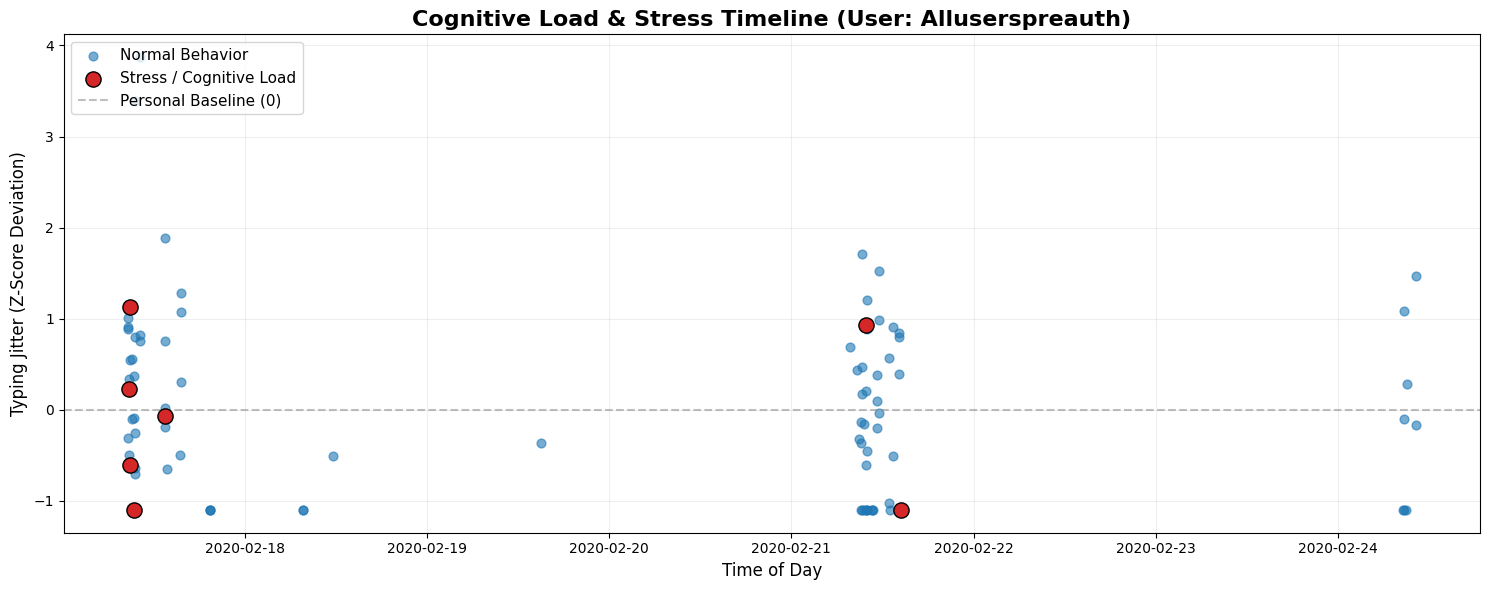

In [ ]:
import matplotlib.pyplot as plt

# 1. Pick a single user to visualize clearly
sample_user = final_ml_dataset['user'].unique()[0]
user_plot_data = final_ml_dataset[final_ml_dataset['user'] == sample_user].copy()

# 2. Set up the canvas
plt.figure(figsize=(15, 6))

# 3. Plot the Normal windows (Blue)
normal_points = user_plot_data[user_plot_data['is_anomalous'] == 1]
plt.scatter(normal_points['timestamp'], normal_points['key_flight_std'],
            color='#1f77b4', label='Normal Behavior', alpha=0.6, s=40)

# 4. Plot the Stressed/Anomalous windows (Red)
stress_points = user_plot_data[user_plot_data['is_anomalous'] == -1]
plt.scatter(stress_points['timestamp'], stress_points['key_flight_std'],
            color='#d62728', label='Stress / Cognitive Load', s=120, edgecolor='black', zorder=5)

# 5. Formatting to make it look professional for your deadline
plt.title(f"Cognitive Load & Stress Timeline (User: {sample_user})", fontsize=16, fontweight='bold')
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Typing Jitter (Z-Score Deviation)", fontsize=12)

# Draw a line at 0 to show the user's perfect normal baseline
plt.axhline(0, color='grey', linestyle='--', alpha=0.5, label='Personal Baseline (0)')

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()

# Show the plot!
plt.show()

In [ ]:
import pandas as pd

# 1. Create our synthetic test cases
test_cases = {
    # THE CALM TYPIST
    # Everything is near 0. They are typing exactly at their normal rhythm and speed.
    'Calm_State': [
        0.1,   # mouse_vel_mean
        0.0,   # mouse_vel_std
        0.2,   # mouse_total_dist
        0.1,   # key_press_count
        0.0,   # backspace_count
        0.0,   # key_dwell_mean
        0.1,   # key_dwell_std (Consistent hold times)
        -0.1,  # key_flight_mean
        0.0,   # key_flight_std (Smooth, rhythmic typing)
        0.0    # error_rate
    ],

    # THE JITTERY / STRESSED TYPIST
    # We spike the Standard Deviations (Jitter) and Error Rates to simulate heavy cognitive load.
    'Jittery_State': [
        0.5,   # mouse_vel_mean
        2.5,   # mouse_vel_std (Erratic, jerky mouse movements)
        0.2,   # mouse_total_dist
        -1.0,  # key_press_count (Typing overall slower because they are thinking)
        4.0,   # backspace_count (Smashing the backspace key)
        0.5,   # key_dwell_mean
        3.5,   # key_dwell_std (Holding keys down for wildly different amounts of time)
        1.0,   # key_flight_mean
        4.5,   # key_flight_std (Massive arrhythmia/pausing between keys)
        3.0    # error_rate (High typo percentage)
    ]
}

# 2. Convert to a DataFrame so the model can read it
test_df = pd.DataFrame.from_dict(test_cases, orient='index', columns=feature_cols)

print("Testing the SVM Model...\n")
print("Input Data (Z-Scores):")
print(test_df)
print("\n--------------------------------")

# 3. Ask the model to predict!
predictions = svm_model.predict(test_df)

# 4. Display the results clearly
print("\nMODEL VERDICT:")
for state_name, prediction in zip(test_df.index, predictions):
    if prediction == 1:
        print(f"[{state_name}] -> 1 (Normal)")
    else:
        print(f"[{state_name}] -> -1 (ANOMALY / STRESS DETECTED!)")

Testing the SVM Model...

Input Data (Z-Scores):
               mouse_vel_mean  mouse_vel_std  mouse_total_dist  \
Calm_State                0.1            0.0               0.2   
Jittery_State             0.5            2.5               0.2   

               key_press_count  backspace_count  key_dwell_mean  \
Calm_State                 0.1              0.0             0.0   
Jittery_State             -1.0              4.0             0.5   

               key_dwell_std  key_flight_mean  key_flight_std  error_rate  
Calm_State               0.1             -0.1             0.0         0.0  
Jittery_State            3.5              1.0             4.5         3.0  

--------------------------------

MODEL VERDICT:
[Calm_State] -> 1 (Normal)
[Jittery_State] -> -1 (ANOMALY / STRESS DETECTED!)


In [ ]:
import joblib

# Save the trained SVM model
joblib.dump(svm_model, 'stress_svm_model.pkl')

print("Model saved! Download 'stress_svm_model.pkl' from the Colab file browser to your laptop.")

Model saved! Download 'stress_svm_model.pkl' from the Colab file browser to your laptop.
